<a href="https://colab.research.google.com/github/MCarvajalR/BootcampTalentoTech/blob/main/experiencia/Identificacion_de_rostros_opencv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Saving istockphoto-153261098-612x612.jpg to istockphoto-153261098-612x612.jpg


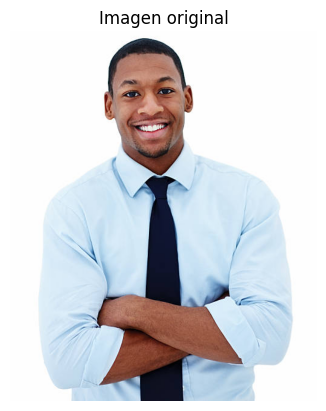

In [ ]:
uploaded = files.upload()

for fn in uploaded.keys():
    img = cv2.imread(fn)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertimos a RGB para mostrar
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("Imagen original")
    plt.show()

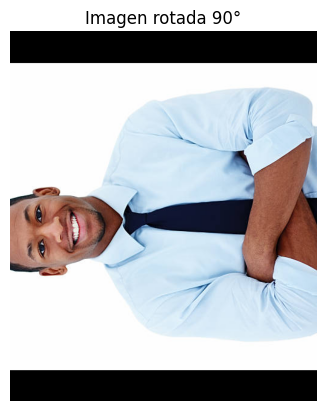

In [ ]:
def rotate_image(image, angle):
    h, w = image.shape[:2]
    center = (w//2, h//2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)  # Matriz de rotación
    rotated = cv2.warpAffine(image, M, (w, h))
    return rotated

rotated_img = rotate_image(img_rgb, 90)  # Rotar 45 grados
plt.imshow(rotated_img)
plt.axis('off')
plt.title("Imagen rotada 90°")
plt.show()

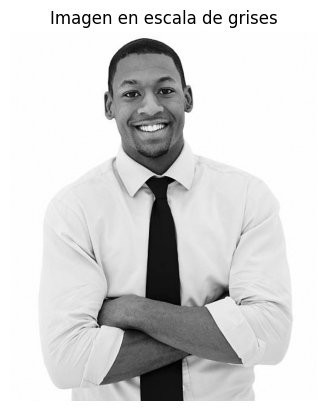

In [ ]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.title("Imagen en escala de grises")
plt.show()

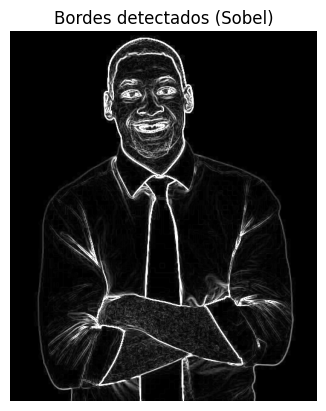

In [ ]:
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Magnitud del gradiente
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.uint8(np.clip(sobel_mag, 0, 255))

plt.imshow(sobel_mag, cmap='gray')
plt.axis('off')
plt.title("Bordes detectados (Sobel)")
plt.show()

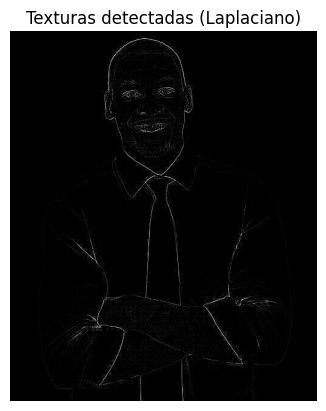

In [ ]:
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = np.uint8(np.clip(laplacian, 0, 255))

plt.imshow(laplacian, cmap='gray')
plt.axis('off')
plt.title("Texturas detectadas (Laplaciano)")
plt.show()

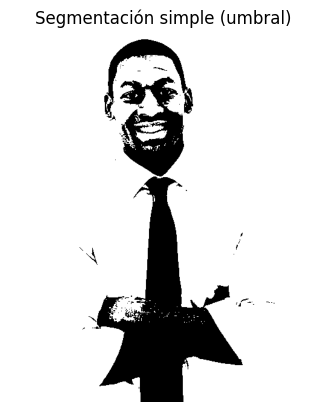

In [ ]:
_, thresh = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)
plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.title("Segmentación simple (umbral)")
plt.show()

In [ ]:
# Crear carpetas para almacenar imágenes de referencia
import os
os.makedirs("reference", exist_ok=True)

In [ ]:
def preprocess_image(image):
    """
    Convierte a gris, detecta bordes y texturas,
    y normaliza la imagen.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Bordes
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    edges = np.sqrt(sobel_x**2 + sobel_y**2)
    edges = np.uint8(np.clip(edges, 0, 255))

    # Textura
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    laplacian = np.uint8(np.clip(laplacian, 0, 255))

    # Combinamos bordes y texturas
    processed = cv2.addWeighted(edges, 0.7, laplacian, 0.3, 0)

    # Normalizamos para comparación
    processed = processed.astype(np.float32) / 255.0
    return processed

Saving istockphoto-153261098-612x612.jpg to istockphoto-153261098-612x612 (1).jpg


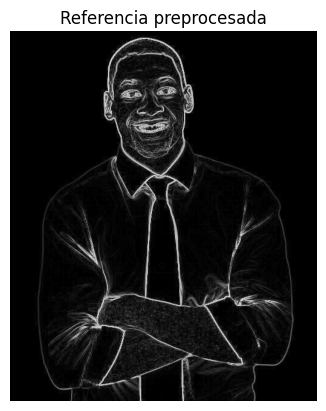

In [ ]:
uploaded = files.upload()

# Solo tomamos la primera imagen
for fn in uploaded.keys():
    ref_img = cv2.imread(fn)
    ref_processed = preprocess_image(ref_img)
    # Guardamos la imagen de referencia preprocesada
    np.save("reference/ref_processed.npy", ref_processed)

    plt.imshow(ref_processed, cmap='gray')
    plt.axis('off')
    plt.title("Referencia preprocesada")
    plt.show()

Saving istockphoto-154126041-612x612.jpg to istockphoto-154126041-612x612.jpg


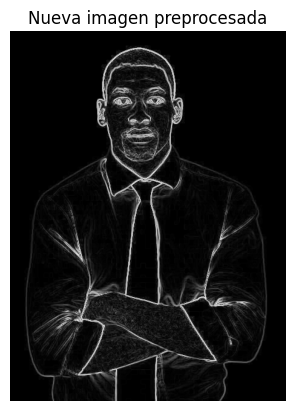

In [ ]:
uploaded_new = files.upload()

for fn in uploaded_new.keys():
    new_img = cv2.imread(fn)
    new_processed = preprocess_image(new_img)

    plt.imshow(new_processed, cmap='gray')
    plt.axis('off')
    plt.title("Nueva imagen preprocesada")
    plt.show()

In [ ]:
# Cargamos la referencia preprocesada
ref_processed = np.load("reference/ref_processed.npy")

# Redimensionamos la nueva imagen al tamaño de la referencia
new_resized = cv2.resize(new_processed, (ref_processed.shape[1], ref_processed.shape[0]))

# Calculamos similitud (correlación)
similarity = np.sum(ref_processed * new_resized) / (np.sqrt(np.sum(ref_processed**2)) * np.sqrt(np.sum(new_resized**2)))

print(f"Similitud entre referencia y nueva imagen: {similarity:.3f}")

# Umbral simple para "coincidencia"
threshold = 0.4
if similarity > threshold:
    print("✅ Persona reconocida")
else:
    print("❌ Persona NO reconocida")

Similitud entre referencia y nueva imagen: 0.447
✅ Persona reconocida
